Compare with Tide Gauges
========================

This ({nb-download}`notebook <Compare-Tide-Gauges.ipynb>`) compares model predictions with tide gauge data provided by the [University of Hawaii Sea Level Center](https://uhslc.soest.hawaii.edu/network/), and computes a local solution from the tide gauge data

```{important}
*Need to download tide model prior to running this notebook.*  
```

OTIS format tidal solutions provided by Oregon State University and ESR  
- [http://volkov.oce.orst.edu/tides/region.html](http://volkov.oce.orst.edu/tides/region.html) 
- [https://www.esr.org/research/polar-tide-models/list-of-polar-tide-models/](https://www.esr.org/research/polar-tide-models/list-of-polar-tide-models/)
- [ftp://ftp.esr.org/pub/datasets/tmd/](ftp://ftp.esr.org/pub/datasets/tmd/)  

Global Tide Model (GOT) solutions provided by Richard Ray at GSFC  
- [https://earth.gsfc.nasa.gov/geo/data/ocean-tide-models](https://earth.gsfc.nasa.gov/geo/data/ocean-tide-models)

Finite Element Solution (FES) provided by AVISO  
- [https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes.html](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes.html)
        
## Python Dependencies
 - [numpy: Scientific Computing Tools For Python](https://www.numpy.org)  
 - [scipy: Scientific Tools for Python](https://www.scipy.org/)  
 - [pyproj: Python interface to PROJ library](https://pypi.org/project/pyproj/)  
 - [netCDF4: Python interface to the netCDF C library](https://unidata.github.io/netcdf4-python/)  
 - [matplotlib: Python 2D plotting library](http://matplotlib.org/)  
 - [cartopy: Python package designed for geospatial data processing](https://scitools.org.uk/cartopy/docs/latest/)  

## Program Dependencies

- `crs.py`: Coordinate Reference System (CRS) routines  
- `io.model.py`: retrieves tide model parameters for named tide models  
- `io.OTIS.py`: extract tidal harmonic constants from OTIS tide models  
- `io.ATLAS.py`: extract tidal harmonic constants from ATLAS netcdf models  
- `io.GOT.py`: extract tidal harmonic constants from GOT tide models  
- `io.FES.py`: extract tidal harmonic constants from FES tide models  
- `solve.py`: estimates the harmonic constants for ocean tides
- `time.py`: utilities for calculating time operations

```{note}
This notebook uses Jupyter widgets to set parameters for calculating the tidal values.  
```

## Load modules

In [1]:
from __future__ import print_function

import ipywidgets
import numpy as np
import scipy.signal
import h5netcdf
import IPython.display
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# import tide programs
import pyTMD.tools
import pyTMD.compute
import pyTMD.solve
import pyTMD.utilities
import timescale
# autoreload
%load_ext autoreload
%autoreload 2

## Set parameters for program

- Model directory  
- Tide model  

In [2]:
# available model list
model_list = sorted(pyTMD.io.model.ocean_elevation())
# display widgets for setting directory and model
TMDwidgets = pyTMD.tools.widgets()
TMDwidgets.model.options = model_list
TMDwidgets.model.value = 'GOT4.10_nc'
TMDwidgets.VBox([
    TMDwidgets.directory,
    TMDwidgets.model,
])

## Find Tide Gauge Data

In [3]:
# remote directory with tide gauge data
HOST = 'https://uhslc.soest.hawaii.edu/data/netcdf/rqds/global/hourly/'
f = pyTMD.utilities.uhslc_list(HOST, pattern=r'(.*?).nc', sort=True)
# create dropdown with all tide gauge data
TMDwidgets.gauges = ipywidgets.Dropdown(
    options=f,
    value=f[0],
    description='Tide Gauges:',
    disabled=False,
    style=TMDwidgets.style,
)
display(TMDwidgets.gauges)

Dropdown(description='Tide Gauges:', options=('h001a.nc', 'h001b.nc', 'h001c.nc', 'h002a.nc', 'h002b.nc', 'h00…

## Download and Read Tide Gauge Data

In [4]:
# open tide gauge data
gauge = TMDwidgets.gauges.value
fid = pyTMD.utilities.from_http([HOST, gauge])
with h5netcdf.File(fid) as fileID:
    # read time and station name
    delta_time = fileID.variables['time'][:].squeeze()
    date_string = fileID.variables['time'].attrs.get("units", "")
    station_name = b''.join(fileID.variables['station_name'][:]).decode('utf-8')
    print(f'{gauge}: {station_name}')
    # get station latitude and longitude
    lat, = fileID.variables['lat'][:]
    lon, = fileID.variables['lon'][:]
    # get sea level heights
    sea_level = np.ma.array(fileID.variables['sea_level'][:].squeeze())
    units = fileID.variables['sea_level'].attrs.get("units", "")
# reduce to valid points
valid = np.logical_not(sea_level.mask | np.isnan(sea_level))
# convert time
epoch, to_sec = timescale.time.parse_date_string(date_string)
ts = timescale.from_deltatime(delta_time[valid]*to_sec, epoch=epoch)
deltat = ts.tt_ut1
print(f'{ts.min().to_datetime()[0]}')
print(f'{ts.max().to_datetime()[0]}')
# remove the mean from the sea level time series
h = (sea_level.compressed() - sea_level[valid].mean())

h001a.nc: Pohnpei
1969-05-08T13:00:00.028798976
1971-02-28T11:59:59.999999488


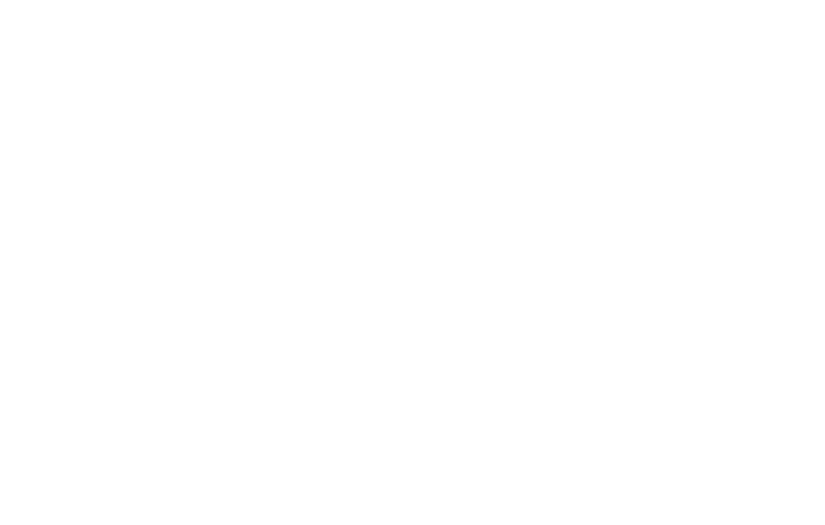

In [5]:
%matplotlib widget
# check coordinates on tide grid
f1 = plt.figure(num=1, clear=True, figsize=(8.25,5.25))
ax1 = f1.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
point, = ax1.plot(lon, lat, 'r*', transform=ccrs.PlateCarree())
# add title
ax1.set_title(f'{station_name} ({lat:0.2f}\u00B0N, {lon:0.2f}\u00B0E)')
# add coastlines
ax1.coastlines()
ax1.add_feature(cfeature.LAND, facecolor='0.85')
# axis = equal
ax1.set_aspect('equal', adjustable='box')
# no ticks on the x and y axes
ax1.get_xaxis().set_ticks([])
ax1.get_yaxis().set_ticks([])
ax1.set_extent([-180, 180, -90, 90])
# stronger linewidth on frame
ax1.spines['geo'].set_linewidth(2.0)
ax1.spines['geo'].set_capstyle('projecting')
# adjust subplot within figure
f1.tight_layout()
plt.show()

In [6]:
RUNS = 100
CONSTANTS = ['m2', 's2', 'n2', 'k2', 'k1', 'o1', 'p1', 'q1', '2n2', 's1', 'm4']
hci = np.zeros((RUNS, len(CONSTANTS)), dtype=np.complex128)
for N in range(RUNS):
    # randomly sample from water level time series
    h_rand = h + (-1.0 + 2.0*np.random.randn(*h.shape)) * h.std()
    ds = pyTMD.solve.constants(ts.tide, h_rand,
        constituents=CONSTANTS, corrections='GOT',
        infer_minor=False, deltat=ts.tt_ut1)
    hci[N, :] = ds.tmd.to_dataarray()
# calculate mean and stdev values of complex harmonic constants
hc = np.mean(hci, axis=0)
hc_std = np.std(hci, axis=0)
# calculate amplitude
amp = np.abs(hc)
# calculate phase in degrees
ph = np.degrees(np.arctan2(hc.imag, hc.real))
# amplitude uncertainty
comp1 = hc_std.real*hc.real/amp
comp2 = hc_std.imag*hc.imag/amp
amp_sigma = np.sqrt(comp1**2 + comp2**2)
# phase uncertainty (degrees)
comp1 = hc_std.real*hc.imag/(amp**2)
comp2 = hc_std.imag*hc.real/(amp**2)
ph_sigma = np.degrees(np.sqrt(comp1**2 + comp2**2))
for i, c in enumerate(CONSTANTS):
    print(f'{c}: amplitude = {amp[i]:.3f} +/- {amp_sigma[i]:.3f} {units}, '
        f'phase = {ph[i]:.2f} +/- {ph_sigma[i]:.2f} degrees')

m2: amplitude = 276.987 +/- 5.753 millimeters, phase = -126.17 +/- 1.63 degrees
s2: amplitude = 191.337 +/- 7.487 millimeters, phase = -145.68 +/- 1.53 degrees
n2: amplitude = 47.184 +/- 6.919 millimeters, phase = -134.92 +/- 8.43 degrees
k2: amplitude = 55.956 +/- 5.915 millimeters, phase = -140.65 +/- 4.97 degrees
k1: amplitude = 162.975 +/- 3.879 millimeters, phase = -62.89 +/- 2.66 degrees
o1: amplitude = 97.820 +/- 5.842 millimeters, phase = -41.36 +/- 3.01 degrees
p1: amplitude = 52.307 +/- 4.872 millimeters, phase = -59.67 +/- 9.12 degrees
q1: amplitude = 18.083 +/- 7.732 millimeters, phase = -24.42 +/- 11.12 degrees
2n2: amplitude = 5.599 +/- 8.702 millimeters, phase = -149.98 +/- 51.46 degrees
s1: amplitude = 7.318 +/- 3.969 millimeters, phase = 65.88 +/- 69.40 degrees
m4: amplitude = 2.132 +/- 8.619 millimeters, phase = -32.30 +/- 146.42 degrees


## Predict tides at measurement times

In [7]:
# get model parameters
model = pyTMD.io.model(verify=False).from_database(TMDwidgets.model.value)
# calculate tide elevations
tide = pyTMD.compute.tide_elevations(lon, lat, ts.to_datetime(),
    directory=TMDwidgets.directory.value, type='time series', 
    model=TMDwidgets.model.value, compressed=TMDwidgets.compress.value,
    crs=4326, standard='datetime', extrapolate=True, cutoff=20)
tide = tide.tmd.to_units(units)

## Adjust global solution for regional data

In [8]:
# use constituents from original model
model.parse_constituents(group='z')
# c = model.constituents
# c = CONSTANTS
c = ["sa","ssa","mm","mf","alpha1","2q1","sigma1","q1","rho1","o1","tau1","beta1","m1","chi1","pi1","p1","s1","k1","psi1","phi1","theta1","j1","so1","oo1","ups1","q1'","m1'","j1'","eps2","2n2","mu2","n2","nu2","gamma2","alpha2","m2","beta2","delta2","lambda2","l2","l2b","t2","s2","r2","k2","eta2","zeta2","n2'","l2'","m3","m4","ms4"]
hc = pyTMD.solve.constants(ts.tide, h-tide.values, c,
    deltat=deltat, corrections=model.corrections)
sol = pyTMD.predict.time_series(ts.tide, hc,
    deltat=deltat, corrections=model.corrections)
sol.values += tide.values

## Calculate Periodograms to Compare Frequencies

In [9]:
# create array of angular frequencies
N = 1000
# frequency range (use Sa to M4)
sa, = pyTMD.constituents.frequency('sa')
m4, = pyTMD.constituents.frequency('m4')
omega = np.linspace(sa, m4, N)
# calculate Lomb-Scargle periodograms
lssa_h = scipy.signal.lombscargle(ts.J2000, h, omega, normalize=True)
lssa_tide = scipy.signal.lombscargle(ts.J2000, tide, omega, normalize=True)
lssa_sol = scipy.signal.lombscargle(ts.J2000, sol, omega, normalize=True)

## Compare predictions and measured values

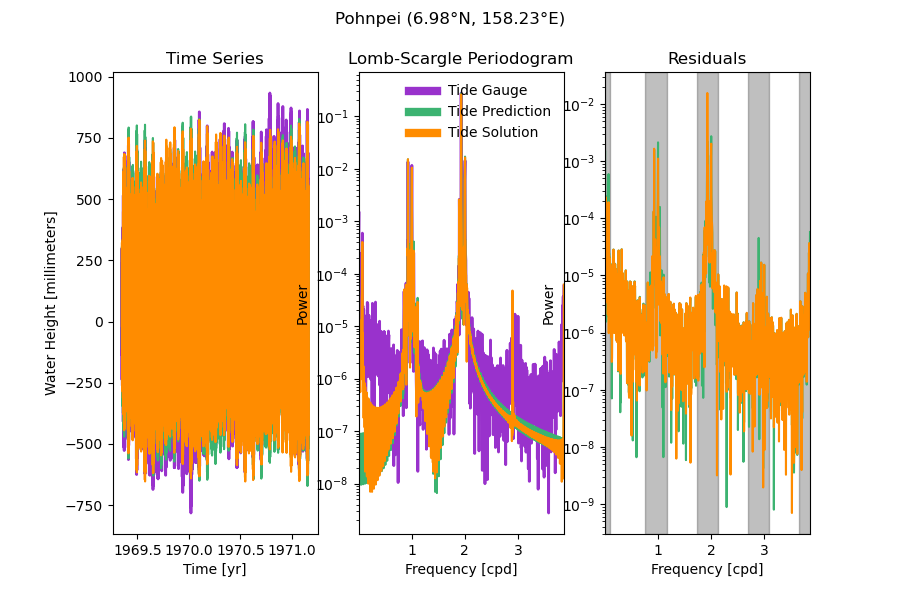

In [10]:
# frequency bands for estimating background noise levels
# in radians per second
frequency_bands = np.array(
    [
        [1.75e-7, 7.28e-6],
        [5.57e-5, 8.48e-5],
        [1.26e-4, 1.55e-4],
        [1.96e-4, 2.25e-4],
        [2.66e-4, 2.96e-4],
        [3.37e-4, 3.66e-4],
        [4.07e-4, 4.38e-4],
        [4.54e-4, 5.06e-4],
        [5.24e-4, 8.73e-4]
    ]
)

%matplotlib widget
# create figure
f2 = plt.figure(num=2, clear=True, figsize=(9, 6))
ax2 = f2.subplots(ncols=3)
# plot time series results
ax2[0].plot(ts.year, h, label='Tide Gauge', lw=2, color='darkorchid')
ax2[0].plot(ts.year, tide, label='Tide Prediction', color='mediumseagreen')
ax2[0].plot(ts.year, sol, label='Tide Solution', color='darkorange')
# plot Lomb-Scargle power
# convert to cycles per solar day
f = omega*86400.0/(2.0*np.pi)
ax2[1].semilogy(f, lssa_h, label='Tide Gauge', lw=2, color='darkorchid')
ax2[1].semilogy(f, lssa_tide, label='Tide Prediction', color='mediumseagreen')
ax2[1].semilogy(f, lssa_sol, label='Tide Solution', color='darkorange')
# plot residuals in periodograms
for band in frequency_bands:
    ax2[2].axvspan(band[0]*86400.0/(2.0*np.pi), band[1]*86400.0/(2.0*np.pi),
        color='k', alpha=0.25)
ax2[2].semilogy(f, np.abs(lssa_h - lssa_tide), label='Tide Prediction', color='mediumseagreen')
ax2[2].semilogy(f, np.abs(lssa_h - lssa_sol), label='Tide Solution', color='darkorange')
# add figure and axes titles
f2.suptitle(f'{station_name} ({lat:0.2f}\u00B0N, {lon:0.2f}\u00B0E)')
ax2[0].set_title('Time Series')
ax2[1].set_title('Lomb-Scargle Periodogram')
ax2[2].set_title('Residuals')
# add labels
ax2[0].set_xlabel('Time [yr]')
ax2[0].set_ylabel(f'Water Height [{units}]')
ax2[1].set_xlabel('Frequency [cpd]')
ax2[1].set_ylabel('Power')
ax2[1].set_xlim(f.min(), f.max())
ax2[2].set_xlabel('Frequency [cpd]')
ax2[2].set_ylabel('Power')
ax2[2].set_xlim(f.min(), f.max())
# add legend
lgd = ax2[1].legend(frameon=False)
lgd.get_frame().set_alpha(1.0)
for line in lgd.get_lines():
    line.set_linewidth(6)
plt.show()

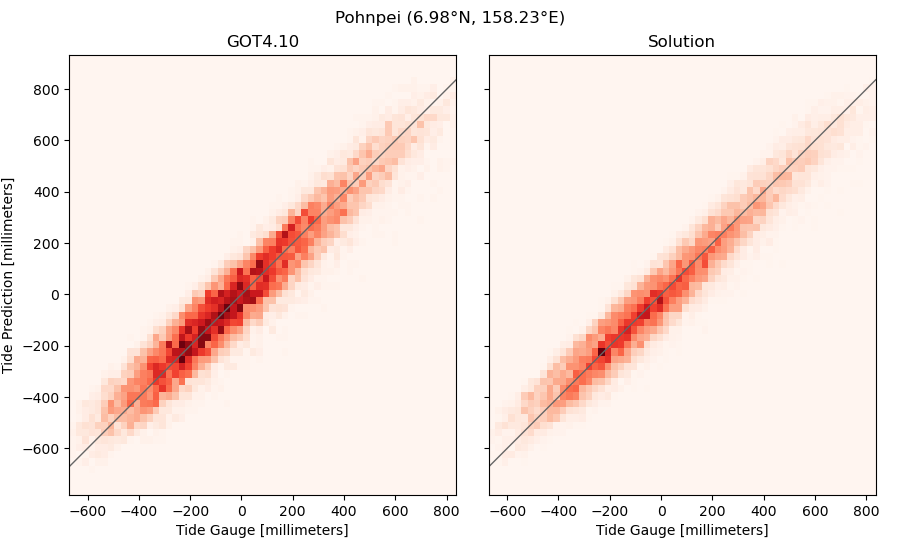

In [11]:
%matplotlib widget
# create figure
f3 = plt.figure(num=3, clear=True, figsize=(9, 5.5))
ax3 = f3.subplots(ncols=2, sharex=True, sharey=True)
xmin = np.minimum(tide.values.min(), sol.values.min())
xmax = np.maximum(tide.values.max(), sol.values.max())
ymin = np.minimum(h.min(), tide.values.min())
ymax = np.maximum(h.max(), tide.values.max())
ax3[0].hist2d(h, tide.values, bins=60, range=((xmin, xmax), (ymin, ymax)), cmap='Reds')
ax3[1].hist2d(h, sol.values, bins=60, range=((xmin, xmax), (ymin, ymax)), cmap='Reds')
ax3[0].axline((0, 0), slope=1, color='0.4', lw=1.0)
ax3[1].axline((0, 0), slope=1, color='0.4', lw=1.0)
ax3[0].set_xlabel(f'Tide Gauge [{units}]')
ax3[1].set_xlabel(f'Tide Gauge [{units}]')
ax3[0].set_ylabel(f'Tide Prediction [{units}]')
ax3[0].set_title(model.name)
ax3[1].set_title('Solution')
ax3[0].set_aspect('equal', adjustable='box')
ax3[1].set_aspect('equal', adjustable='box')
f3.suptitle(f'{station_name} ({lat:0.2f}\u00B0N, {lon:0.2f}\u00B0E)')
# adjust subplot within figure
f3.subplots_adjust(left=0.075,right=0.975,bottom=0.1,top=0.90, wspace=0.075)